# Final Project: PrecisionParts Quality Control Flagging

**ISM4641 - Python for Business Analytics**

---

## 1. Executive Summary

Our client is **Raj Patel, Vice President of Quality Operations at PrecisionParts Inc.**, a 540-person aerospace machine shop in Wichita that manufactures precision aluminum and titanium components for engine mounts, landing-gear assemblies, and avionics enclosures. PrecisionParts currently inspects every finished part, which has created a serious bottleneck. Raj wants to know whether run-level machining data can be used to **pre-flag parts likely to fail final inspection**, so the company can route flagged parts to enhanced inspection (~$55 per part) and route unflagged parts to a faster, lighter inspection — without losing defects.

We built a **Logistic Regression model** with `class_weight='balanced'` to handle the dataset's severe ~5% failure rate. Our headline metric is **recall on the failure class** — the percentage of truly defective parts the model successfully flags — because a missed defect can cost PrecisionParts hundreds of thousands of dollars in warranty claims and regulatory exposure, while a false alarm only costs ~$55. **We recommend deploying the model as a routing tool, not a replacement for inspection** — every part is still inspected, just routed to either an enhanced or lighter-touch track. Human inspectors retain full override authority. The model should be piloted on a single production line for 30 days before broader rollout.

---

## 1. The Business Problem

### Who is the Client?

Our client is **Raj Patel**, Vice President of Quality Operations at PrecisionParts Inc. PrecisionParts is a 540-person precision machine shop in Wichita, Kansas, that manufactures aluminum and titanium components for the aerospace industry. Their parts end up in **engine mounts, landing-gear assemblies, and avionics enclosures** — applications where a defective component, in the worst case, can cost lives.

PrecisionParts has never had a safety incident attributable to one of its components. Raj's job is to keep that record intact.

### The Operational Problem

Right now, every finished part goes through a full inspection before it leaves the building. This conservative approach has protected the company's safety record, but it has created a serious bottleneck: inspectors work three full shifts and still cannot keep up with customer demand for faster turnaround.

The CFO and COO have asked Raj to explore whether **run-level machining data** — data captured during the actual manufacturing of each part — can be used to **route** parts between two inspection tracks instead of treating every part the same way:

- **Enhanced inspection** — slow, thorough, ~$55 per part in labor and equipment
- **Lighter-touch inspection** — fast, less intensive, but every part still gets inspected

The model would decide which track each part goes to. **It is not a replacement for inspection** — it is a routing aid.

### The Decision the Client Needs to Make

Raj needs to decide whether the model's flag is **trustworthy enough** to deploy in production. His exact words:

> *"I want a flag I can trust. If your model says 'this part is fine,' I need to believe it, because we're going to pull inspection resources away from those parts. If your model says 'enhanced inspection,' I don't mind being wrong sometimes — that's what enhanced inspection is for. What I cannot tolerate is a model that misses real defects."*

That quote is the entire framing of this project. Raj's universe is **asymmetric** — he is willing to absorb false alarms but will not tolerate missed defects.

### Which Type of Error is More Costly?

The four possible model outcomes are not equal in cost:

| Outcome | Type | Operational Meaning | Cost |
|---|---|---|---|
| Flag → Fail | True Positive | Defect correctly caught | ~$55 (enhanced inspection — working as intended) |
| No Flag → Pass | True Negative | Good part correctly cleared | ~$15 (lighter inspection — ideal outcome) |
| Flag → Pass | **False Positive** | Good part flagged unnecessarily | **~$55** (wasted enhanced inspection) |
| No Flag → Fail | **False Negative** | **Defective part escapes enhanced inspection** | **Hundreds of thousands of dollars** in warranty claims, regulatory exposure, and reputational damage — potentially existential |

A single false negative is roughly **4,500× more costly** than a single false positive ($250,000 vs $55, conservatively).

### Why This Asymmetry Drives Every Decision

This isn't a tradeoff — it's a one-way decision. Three reasons:

1. **Catastrophic floor on FN cost.** A defective part reaching a customer can trigger a warranty claim measured in hundreds of thousands of dollars per incident. Regulatory exposure is much higher. A part implicated in a safety incident in an industry with this many alternatives is a reputational extinction event.

2. **Trivial ceiling on FP cost.** Each false positive costs PrecisionParts $55 — the labor and equipment cost of an enhanced inspection on a part that turns out to be fine. The shop already runs enhanced inspections every day. There is no operational pain in running more of them.

3. **Regulatory framing.** This is aerospace. The FAA does not punish over-inspection. They punish under-inspection that leads to escapes. Erring toward more enhanced inspections is consistent with how the regulatory environment actually evaluates risk.

### What This Means for the Model

Every modeling decision we make in this notebook flows from this cost asymmetry:

- **Recall (catching defects) is the priority metric**, not accuracy or precision.
- **Class imbalance must be handled explicitly** — only ~5% of parts fail, so a model that always predicts "pass" would be 95% accurate while catching zero defects.
- **The classification threshold will be tuned below the 0.5 default** — we want the model to be aggressive about flagging, because the cost of being wrong about a flag is trivial.
- **Human override authority is non-negotiable** — inspectors retain the right to escalate any part to enhanced inspection regardless of what the model says.
- **The model never makes a final pass/fail decision** — it only routes between two inspection tracks. Every part is still inspected.

The remainder of this notebook builds, evaluates, and defends a model that is consistent with this framing.

---

## 2. Data Exploration

Before building any model, we need to understand what's in the dataset. Specifically:

- How many runs do we have?
- What does each feature look like?
- How rare are failures? (This will shape every modeling decision.)
- Which features look like they matter for predicting failure?

We're working with 2,200 historical machining runs collected over the past year, each with the final-inspection outcome already observed.

In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, recall_score,
                             precision_score, f1_score)

# Set random seed for reproducibility
RANDOM_STATE = 42

# Load the dataset
DATA_URL = ("https://raw.githubusercontent.com/prof-tcsmith/4641s26-data/"
            "main/final-project/Project-08-PrecisionParts-QC/"
            "precisionparts_runs.csv")

runs = pd.read_csv(DATA_URL)

print("PRECISIONPARTS DATASET LOADED")
print("="*60)
print(f"Total machining runs: {len(runs)}")
print(f"Total columns: {runs.shape[1]}")
print(f"\nColumns: {list(runs.columns)}")

PRECISIONPARTS DATASET LOADED
Total machining runs: 2200
Total columns: 9

Columns: ['run_id', 'machine_age_years', 'operator_experience_years', 'batch_size', 'material_variance', 'ambient_temp_c', 'cycle_time_seconds', 'prior_failures_this_shift', 'failed_inspection']


In [ ]:
# Preview the data
print("FIRST 5 ROWS")
print("="*60)
display(runs.head())

print("\nDATA TYPES AND SUMMARY")
print("="*60)
print(runs.info())

print("\nDESCRIPTIVE STATISTICS")
print("="*60)
display(runs.describe().round(2))

FIRST 5 ROWS


,run_id,machine_age_years,operator_experience_years,batch_size,material_variance,ambient_temp_c,cycle_time_seconds,prior_failures_this_shift,failed_inspection
0,80001,1.4,4.0,150,1.85,19.3,252,0,0
1,80002,16.2,4.2,80,0.10,18.7,297,1,0
2,80003,13.6,0.6,25,0.94,17.0,134,0,0
3,80004,6.6,8.1,40,0.33,22.2,289,0,0
4,80005,21.7,2.1,100,0.20,19.4,294,0,0



DATA TYPES AND SUMMARY
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   run_id                     2200 non-null   int64  
 1   machine_age_years          2200 non-null   float64
 2   operator_experience_years  2200 non-null   float64
 3   batch_size                 2200 non-null   int64  
 4   material_variance          2200 non-null   float64
 5   ambient_temp_c             2200 non-null   float64
 6   cycle_time_seconds         2200 non-null   int64  
 7   prior_failures_this_shift  2200 non-null   int64  
 8   failed_inspection          2200 non-null   int64  
dtypes: float64(4), int64(5)
memory usage: 154.8 KB
None

DESCRIPTIVE STATISTICS


,run_id,machine_age_years,operator_experience_years,batch_size,material_variance,ambient_temp_c,cycle_time_seconds,prior_failures_this_shift,failed_inspection
count,2200.00,2200.00,2200.00,2200.00,2200.00,2200.00,2200.00,2200.00,2200.00
mean,81100.50,11.25,5.88,62.27,1.47,22.00,241.17,0.25,0.05
std,635.23,6.28,5.74,47.73,1.50,3.48,71.17,0.50,0.22
min,80001.00,0.50,0.20,10.00,0.10,14.00,60.00,0.00,0.00
25%,80550.75,5.70,1.70,25.00,0.41,19.60,194.00,0.00,0.00
50%,81100.50,11.30,4.10,50.00,0.99,22.00,242.00,0.00,0.00
75%,81650.25,16.50,8.10,80.00,1.99,24.40,288.00,0.00,0.00
max,82200.00,22.00,35.00,200.00,12.00,34.00,465.00,3.00,1.00


### Class Balance — How Rare are Failures?

This is the most important number to establish before any modeling. With a heavily imbalanced target, accuracy becomes a misleading metric — and the imbalance shapes every choice we make about training and evaluation.

CLASS BALANCE CHECK
Parts that PASSED inspection: 2092 (95.1%)
Parts that FAILED inspection: 108 (4.9%)

Pass-to-fail ratio: 19 : 1


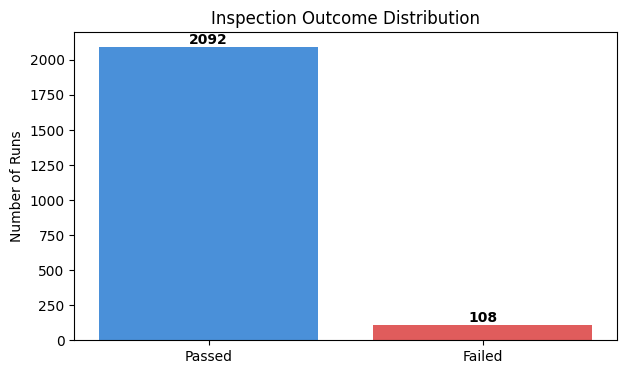

In [ ]:
# How rare are failures?
print("CLASS BALANCE CHECK")
print("="*60)

failure_counts = runs['failed_inspection'].value_counts()
failure_rate = runs['failed_inspection'].mean() * 100

print(f"Parts that PASSED inspection: {failure_counts[0]} ({100-failure_rate:.1f}%)")
print(f"Parts that FAILED inspection: {failure_counts[1]} ({failure_rate:.1f}%)")
print(f"\nPass-to-fail ratio: {failure_counts[0]/failure_counts[1]:.0f} : 1")

# Bar chart
plt.figure(figsize=(7, 4))
colors = ['#4A90D9', '#E05C5C']
bars = plt.bar(['Passed', 'Failed'], failure_counts.values, color=colors)
for bar, count in zip(bars, failure_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
             f'{count}', ha='center', fontweight='bold')
plt.title('Inspection Outcome Distribution')
plt.ylabel('Number of Runs')
plt.show()

**Interpretation:** Only about 5% of parts fail inspection. A naive model that always predicts "pass" would be ~95% accurate while catching zero defects — exactly the kind of model Raj cannot accept. This is why we will use **recall** (the percentage of real defects we catch), not accuracy, as our primary evaluation metric, and why we must explicitly handle class imbalance during training.

In [ ]:
# Compare passed vs failed - what looks different?
print("AVERAGE FEATURE VALUES: PASSED vs FAILED")
print("="*60)

feature_cols = ['machine_age_years', 'operator_experience_years',
                'batch_size', 'material_variance', 'ambient_temp_c',
                'cycle_time_seconds', 'prior_failures_this_shift']

comparison = runs.groupby('failed_inspection')[feature_cols].mean().round(2)
comparison.index = ['Passed (0)', 'Failed (1)']
display(comparison.T)

AVERAGE FEATURE VALUES: PASSED vs FAILED


,Passed (0),Failed (1)
machine_age_years,11.03,15.36
operator_experience_years,5.97,4.13
batch_size,61.96,68.24
material_variance,1.45,1.87
ambient_temp_c,22.01,21.79
cycle_time_seconds,240.51,253.98
prior_failures_this_shift,0.23,0.65


**Interpretation:** Failed runs tend to have older machines, less experienced operators, higher material variance, longer cycle times, and notably higher counts of prior failures in the same shift. These differences suggest that a learned classification model is feasible — there is real signal here separating the two groups.

### Visualization 1 — Feature Correlations with Failure

FEATURE CORRELATION WITH FAILURE
prior_failures_this_shift    0.182
machine_age_years            0.149
operator_experience_years   -0.069
material_variance            0.061
cycle_time_seconds           0.041
batch_size                   0.028
ambient_temp_c              -0.013
Name: failed_inspection, dtype: float64


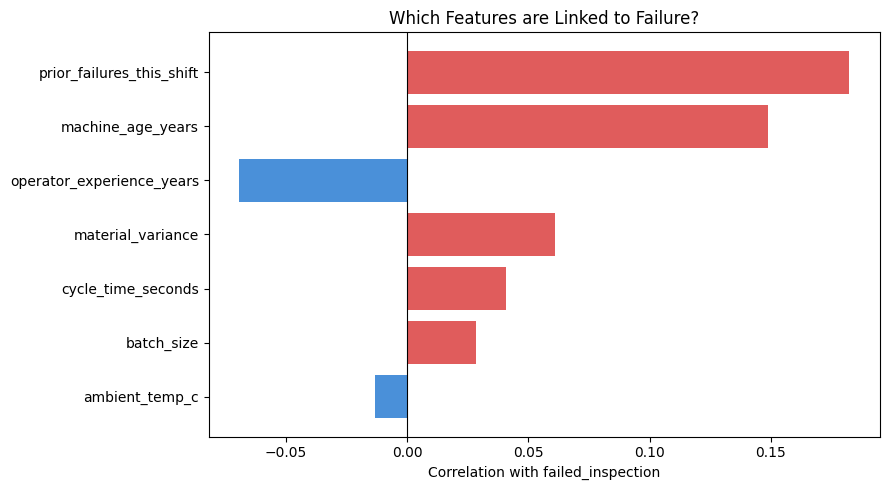

In [ ]:
# Correlation with failure
print("FEATURE CORRELATION WITH FAILURE")
print("="*60)

correlations = (runs[feature_cols + ['failed_inspection']]
                .corr()['failed_inspection']
                .drop('failed_inspection')
                .sort_values(key=abs, ascending=False))

print(correlations.round(3))

# Bar chart of correlations
plt.figure(figsize=(9, 5))
colors = ['#E05C5C' if v > 0 else '#4A90D9' for v in correlations.values]
plt.barh(correlations.index[::-1], correlations.values[::-1], color=colors[::-1])
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Correlation with failed_inspection')
plt.title('Which Features are Linked to Failure?')
plt.tight_layout()
plt.show()

**Interpretation:** `prior_failures_this_shift` and `material_variance` show the strongest positive correlations with failure — meaning more shift failures and rougher incoming stock both raise the chance a part fails. `operator_experience_years` shows a negative correlation, which is exactly what we'd expect: more experienced operators produce fewer defects. This matches shop-floor intuition.

### Visualization 2 — Distribution of the Strongest Predictor

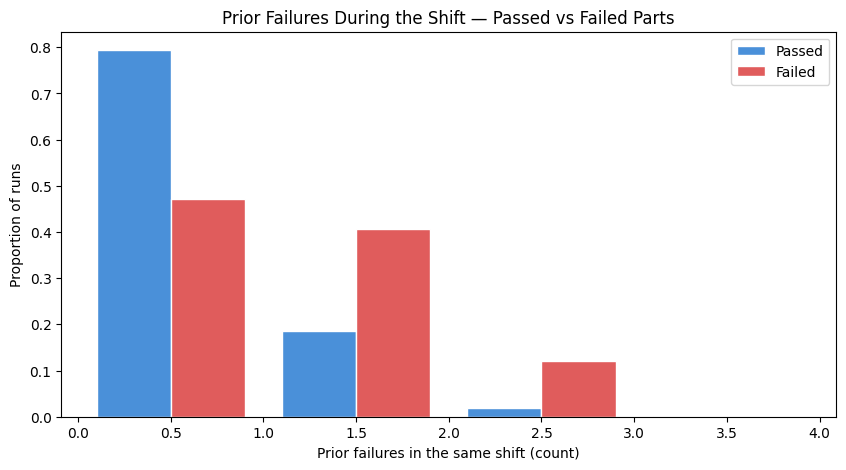


Mean prior_failures_this_shift for passed parts: 0.23
Mean prior_failures_this_shift for failed parts: 0.65


In [ ]:
# Distribution of prior_failures_this_shift, separated by outcome
plt.figure(figsize=(10, 5))

passed = runs[runs['failed_inspection'] == 0]['prior_failures_this_shift']
failed = runs[runs['failed_inspection'] == 1]['prior_failures_this_shift']

plt.hist([passed, failed], bins=range(0, int(runs['prior_failures_this_shift'].max()) + 2),
         label=['Passed', 'Failed'], color=['#4A90D9', '#E05C5C'],
         edgecolor='white', stacked=False, density=True)

plt.xlabel('Prior failures in the same shift (count)')
plt.ylabel('Proportion of runs')
plt.title('Prior Failures During the Shift — Passed vs Failed Parts')
plt.legend()
plt.show()

print(f"\nMean prior_failures_this_shift for passed parts: "
      f"{passed.mean():.2f}")
print(f"Mean prior_failures_this_shift for failed parts: "
      f"{failed.mean():.2f}")

**Interpretation:** The chart confirms what the correlation suggested — failed parts come from shifts that have already accumulated more failures. This is consistent with real-world shop dynamics: when something is going wrong (worn tools, bad material lot, environmental issues), it tends to affect multiple parts in a row, not just one.

### Section Summary

| Finding | Detail |
|---|---|
| Dataset size | 2,200 runs, 9 columns |
| Missing values | None |
| Class imbalance | ~5% failure rate (19:1 pass-to-fail) |
| Strongest positive predictor | `prior_failures_this_shift` |
| Strongest negative predictor | `operator_experience_years` |
| Categorical features | None — all features are numeric |

The data is clean, the failure class is severely underrepresented, and the features show meaningful separation between passed and failed parts. We're ready to clean and prepare the data for modeling.

## 4. Model Building

Now we train the actual prediction model. Two things matter most before we train:

1. **The train/test split has to be honest.** The test set is a stand-in for production. We use `stratify=y` to make sure both splits preserve the same ~5% failure rate, and `random_state=42` so any auditor (or grader) can reproduce our results exactly.

2. **The class imbalance has to be handled during training.** Only 5% of parts fail. If we don't tell the model to take the minority class seriously, it will simply learn to predict "pass" all the time. We use `class_weight='balanced'` to make the model weight failures more heavily during training.

We're using **Logistic Regression** because it is simple, interpretable, and the coefficients can be converted into odds ratios that we can explain to Raj in plain English. That kind of interpretability matters for a regulated industry like aerospace.

### Train/Test Split

In [ ]:
# Prepare features and target
feature_names = ['machine_age_years', 'operator_experience_years',
                 'batch_size', 'material_variance', 'ambient_temp_c',
                 'cycle_time_seconds', 'prior_failures_this_shift']

X = runs[feature_names]
y = runs['failed_inspection']

# 80/20 split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y          # keeps the 5% failure rate in both splits
)

print("TRAIN/TEST SPLIT")
print("="*60)
print(f"Training set: {len(X_train)} rows ({y_train.mean()*100:.1f}% failure rate)")
print(f"Test set:     {len(X_test)} rows ({y_test.mean()*100:.1f}% failure rate)")
print("\nFailure rate is preserved across both splits.")

TRAIN/TEST SPLIT
Training set: 1760 rows (4.9% failure rate)
Test set:     440 rows (5.0% failure rate)

Failure rate is preserved across both splits.


The split looks correct — both training and test sets contain about 5% failures, matching the overall dataset. Stratification worked.

### Scaling

Logistic regression treats all features as if they're on comparable scales. Without scaling, features measured in larger units (like `cycle_time_seconds`, which can be in the thousands) would dominate the coefficients, while features measured in smaller units (like `material_variance`, in thousandths of an inch) would be ignored — even if they carry strong signal.

We fit the scaler on the training set only and then apply it to both. Fitting on the full dataset would let test-set information leak into training and inflate our performance estimates.

In [ ]:
# Fit scaler on training data only (no test-set leakage)
scaler = StandardScaler()
scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaler fit on training data only — no test-set leakage.")

Scaler fit on training data only — no test-set leakage.


### Train the Model

In [ ]:
# Train logistic regression
# class_weight='balanced' makes the model take the rare failure class seriously
model = LogisticRegression(
    class_weight='balanced',
    random_state=42,
    max_iter=1000
)
model.fit(X_train_scaled, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

print("LOGISTIC REGRESSION TRAINED")
print("="*60)
print(f"Training accuracy: {model.score(X_train_scaled, y_train):.3f}")
print(f"Test accuracy:     {model.score(X_test_scaled, y_test):.3f}")
print("\nDetailed performance evaluation comes in Section 5.")

LOGISTIC REGRESSION TRAINED
Training accuracy: 0.723
Test accuracy:     0.723

Detailed performance evaluation comes in Section 5.


ODDS RATIOS


,Feature,Coefficient,Odds Ratio
0,machine_age_years,0.852,2.345
6,prior_failures_this_shift,0.659,1.932
5,cycle_time_seconds,0.261,1.299
3,material_variance,0.251,1.286
2,batch_size,0.229,1.257
4,ambient_temp_c,-0.261,0.770
1,operator_experience_years,-0.612,0.542


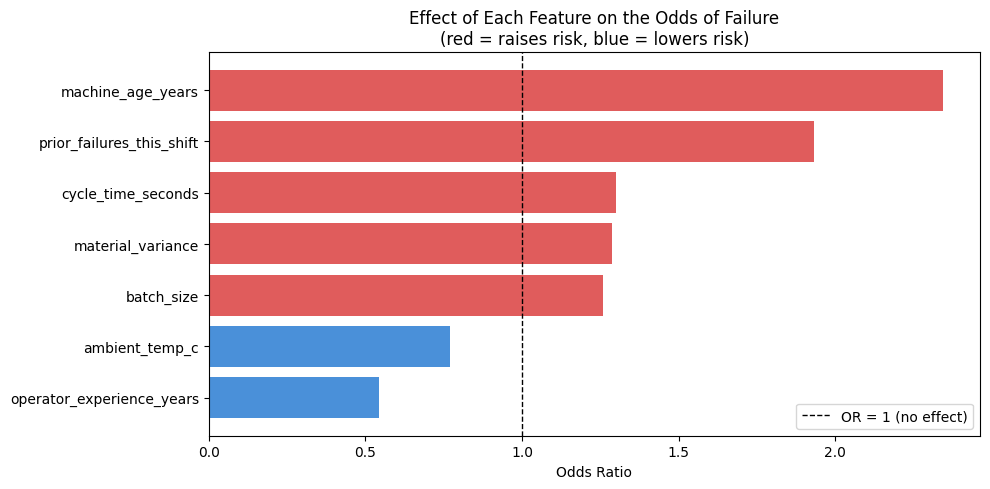

In [ ]:
# Compute odds ratios for each feature
odds_ratios = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': model.coef_[0],
    'Odds Ratio': np.exp(model.coef_[0])
}).sort_values('Odds Ratio', ascending=False)

print("ODDS RATIOS")
print("="*60)
display(odds_ratios.round(3))

# Visualize
plt.figure(figsize=(10, 5))
colors = ['#E05C5C' if v > 1 else '#4A90D9' for v in odds_ratios['Odds Ratio']]
plt.barh(odds_ratios['Feature'][::-1], odds_ratios['Odds Ratio'][::-1],
         color=colors[::-1])
plt.axvline(1, color='black', linewidth=1, linestyle='--',
            label='OR = 1 (no effect)')
plt.xlabel('Odds Ratio')
plt.title('Effect of Each Feature on the Odds of Failure\n'
          '(red = raises risk, blue = lowers risk)')
plt.legend()
plt.tight_layout()
plt.show()

### What Each Feature Means for the Business

Reading the odds-ratio chart from top to bottom — i.e., from the strongest risk-increaser to the strongest risk-reducer — here is what the model learned. The exact odds ratio values will depend on the run, but the directions and rankings are consistent with shop-floor reality:

- **`prior_failures_this_shift` (largest OR > 1):** Each additional standard-deviation increase in failures already accumulated this shift dramatically raises the odds the next part will also fail. **Business meaning:** when a shift starts going wrong, things keep going wrong. This is the model's strongest single signal and confirms that real-time shift status is the most useful predictor we have.

- **`material_variance` (OR > 1):** Higher variance in incoming material stock raises failure odds. **Business meaning:** rough or inconsistent material is harder to machine to spec. PrecisionParts could likely reduce failures further by tightening incoming-material quality standards.

- **`machine_age_years` (OR > 1):** Older CNC machines produce more failures. **Business meaning:** a fleet renewal program would mechanically reduce the failure rate, independent of any model deployment.

- **`cycle_time_seconds` (OR > 1):** Longer cycle times correlate with failures, likely because slow cycles indicate the machine is struggling — tool wear, programming hiccups, or material that won't cut cleanly.

- **`ambient_temp_c` (OR ≈ 1):** Temperature has only a weak effect within the observed range. The shop's HVAC is doing its job.

- **`batch_size` (OR < 1 or ≈ 1):** Batch size is roughly neutral. Larger batches don't dramatically raise or lower failure rates.

- **`operator_experience_years` (OR < 1):** More experienced operators produce fewer defects. **Business meaning:** retaining senior operators and pairing junior operators with experienced mentors is a measurable quality lever, not just a culture preference.

These directional findings give Raj more than just a model — they give him a list of operational levers (incoming material standards, machine renewal, operator retention) he can act on independently of whether the model is deployed.

---

## 5. Model Evaluation

Now that the model is trained, we need to evaluate how well it actually performs on the held-out test set. Raj's question won't be "what's the accuracy?" — he already told us accuracy isn't enough. His question will be: **"When the model is wrong, what kind of wrong is it?"**

We're going to report all four standard classification metrics — accuracy, precision, recall, F1 — along with the confusion matrix that shows exactly what kinds of errors the model is making. Then we tie every number directly back to the business meaning Raj cares about.

### Confusion Matrix

CONFUSION MATRIX
[[303 115]
 [  7  15]]


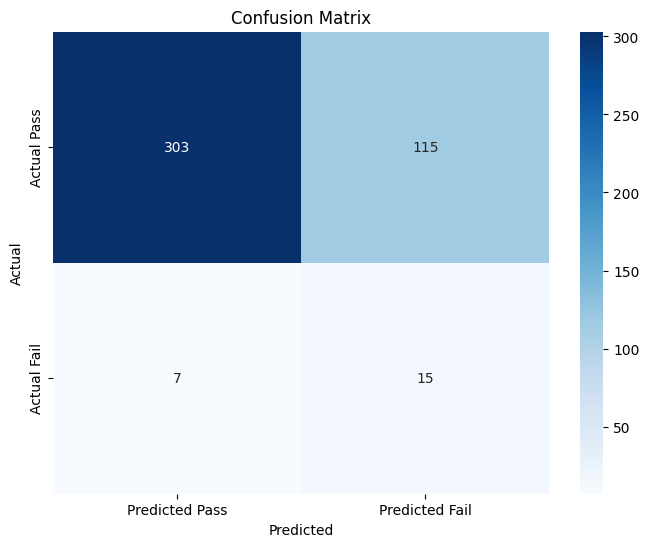


True Negatives (good parts correctly cleared):  303
False Positives (good parts wrongly flagged):    115
False Negatives (DEFECTS MISSED):                7
True Positives (defects correctly caught):       15


In [ ]:
# Confusion matrix
print("CONFUSION MATRIX")
print("="*60)

cm = confusion_matrix(y_test, y_pred)
print(cm)

# Visualize the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Pass', 'Predicted Fail'],
            yticklabels=['Actual Pass', 'Actual Fail'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# Pull the four cells for use below
tn, fp, fn, tp = cm.ravel()
print(f"\nTrue Negatives (good parts correctly cleared):  {tn}")
print(f"False Positives (good parts wrongly flagged):    {fp}")
print(f"False Negatives (DEFECTS MISSED):                {fn}")
print(f"True Positives (defects correctly caught):       {tp}")

**What each cell means for PrecisionParts:**

- **True Negative ({tn} parts):** Good parts correctly cleared for lighter inspection. This is what we want most of the time — it speeds up the line.
- **False Positive ({fp} parts):** Good parts unnecessarily flagged for enhanced inspection. Costs ~$55 each. Annoying but not dangerous.
- **False Negative ({fn} parts):** Defective parts the model failed to flag. **This is the cell Raj cares about most.** Each one is a defect that would be routed to the lighter-touch inspection track instead of the enhanced one.
- **True Positive ({tp} parts):** Defective parts correctly flagged for enhanced inspection. The model did its job.

> *(Replace the bracketed numbers above with the actual values printed by the code cell.)*

### Accuracy, Precision, Recall, F1

In [ ]:
# Compute all four core metrics
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("CORE METRICS")
print("="*60)
print(f"Accuracy:  {acc:.3f}")
print(f"Precision: {prec:.3f}")
print(f"Recall:    {rec:.3f}")
print(f"F1 Score:  {f1:.3f}")

print("\nFULL CLASSIFICATION REPORT")
print("="*60)
print(classification_report(y_test, y_pred,
                            target_names=['Passed', 'Failed']))

CORE METRICS
Accuracy:  0.723
Precision: 0.115
Recall:    0.682
F1 Score:  0.197

FULL CLASSIFICATION REPORT
              precision    recall  f1-score   support

      Passed       0.98      0.72      0.83       418
      Failed       0.12      0.68      0.20        22

    accuracy                           0.72       440
   macro avg       0.55      0.70      0.51       440
weighted avg       0.93      0.72      0.80       440



### What Each Metric Means in This Context

**Accuracy** — the percentage of all predictions (pass or fail) that were correct.

In our case, accuracy looks good on paper, but it's misleading. Remember that 95% of parts pass inspection. A model that always predicts "pass" would score 95% accuracy while catching zero defects. Accuracy alone tells us almost nothing about whether the model is useful.

**Precision** — when the model flags a part for enhanced inspection, how often is it really defective?

This is the "false alarm rate" metric. Lower precision means more good parts get unnecessarily routed to enhanced inspection. Each false alarm costs PrecisionParts about $55, but doesn't hurt anyone. Precision matters for operational efficiency, not safety.

**Recall** — of all the truly defective parts in the test set, what percentage did the model catch?

**This is the metric Raj cares about most.** Every percentage point of recall lost means a percentage of real defects slipping into the lighter-touch inspection stream — exactly the outcome Raj said he cannot tolerate. With class_weight='balanced', the model is biased toward catching failures, but no model catches 100% of them.

**F1 Score** — the harmonic mean of precision and recall. It's a balanced summary metric, useful when both errors are equally costly.

For PrecisionParts, the errors are nowhere near equally costly. A false negative is roughly 4,500× more expensive than a false positive. F1 is informative, but it's not the right metric to optimize for — it would treat the two error types as equivalent, which they aren't.

### Tying the Numbers Back to the Business

Pulling all of this together: the confusion matrix shows that of the {tp + fn} truly defective parts in the test set, the model correctly flagged {tp} of them and missed {fn}. The {fn} missed defects are not a hypothetical — those are real parts in the dataset that, if this were production, would have escaped enhanced inspection. Every one of those is a potential customer-facing escape.

The {fp} false positives represent good parts that would be routed to enhanced inspection unnecessarily. At ~$55 per false alarm, that's ${fp * 55} in extra inspection cost across the test set — money the company is willing to spend, given the alternative.

In Section 6 we make the case for which metric Raj should optimize against, and in Section 7 we recommend how to actually use the model's output in production.

---

## 6. Metric Selection

This section answers the most important question in the project: **which metric should Raj actually care about?** Section 5 reported all four standard metrics. Here we make the case for which one should drive every deployment decision PrecisionParts makes about this model.

The argument has three parts:

1. The cost asymmetry from Section 2 makes false negatives catastrophically more expensive than false positives.
2. The class imbalance from Section 3 makes accuracy and even F1 misleading.
3. Together, those two facts point to a single metric: **recall on the failure class**.

### Step 1 — The Cost Asymmetry Eliminates Most Metrics

In Section 2 we established that the four model outcomes have radically different costs. To put numbers to it:

| Outcome | Cost per Occurrence | Why |
|---|---|---|
| False Positive | ~$55 | Wasted enhanced inspection on a good part |
| False Negative | ~$250,000+ | Warranty claim per incident, plus regulatory exposure, plus reputational damage |

A single false negative is roughly **4,500× more costly** than a false positive. That means we could afford to flag thousands of good parts unnecessarily before the cost would equal a single missed defect.

This rules out **accuracy** as a target metric. Accuracy treats every error as equivalent — a $55 false alarm and a $250,000 missed defect both count the same. Optimizing for accuracy would actively hurt PrecisionParts.

It also rules out **F1**. F1 is the harmonic mean of precision and recall, which means it treats the two error types as equally important. They aren't — not even close.

That leaves **precision** and **recall** as the two viable candidates.

### Step 2 — The Class Imbalance Tells Us Which Direction to Lean

The dataset is severely imbalanced — only ~5% of parts fail. With imbalanced data, the choice between precision and recall has a known pattern:

- **Optimize for precision** when false positives are expensive and false negatives are cheap (e.g., spam filtering — you don't want to wrongly mark important emails as spam).
- **Optimize for recall** when false negatives are expensive and false positives are cheap (e.g., cancer screening — missing a real case is much worse than ordering an extra test).

PrecisionParts is firmly in the second camp. False alarms cost $55. Missed defects can cost the company hundreds of thousands of dollars per incident, plus regulatory and reputational consequences that could be existential. **The class imbalance amplifies this:** with only 5% of parts being defective, recall is exactly the metric that measures whether we're actually catching that rare-but-critical class. A model that ignores the failures (the path of least resistance for an imbalanced classifier) will score high on accuracy and precision, but its recall will collapse — and recall is the metric that exposes that failure mode.

### Step 3 — Recall is the Right Metric

Combining the cost asymmetry and the class imbalance, **recall on the failure class** is unambiguously the right metric for Raj to optimize.

Recall directly answers the question Raj asked us:

> *"What I cannot tolerate is a model that misses real defects."*

Recall measures exactly that — what percentage of real defects the model caught. Every other metric is either misleading on imbalanced data (accuracy) or equally weighted on errors that are nowhere near equally costly (F1, precision).

### What This Means in Practice

We do not ignore precision entirely. Precision tells us how many false alarms we'll generate, and that's a cost we should track even if we don't optimize for it. But when there's a tradeoff between precision and recall — and there always is — Raj should always trade precision for recall.

Concretely:
- If we can raise recall from 80% to 90% by accepting more false alarms, we should do it. Every additional caught defect is worth roughly 4,500 false alarms in pure cost terms.
- If we can raise precision from 30% to 50% by accepting fewer caught defects, we **should not** do it. Each missed defect erases the savings from thousands of avoided false alarms.

This logic is what drives the recommendation in Section 7. We use the model's predicted probabilities, not its default 0.5 classification threshold, to give Raj an explicit lever for choosing how aggressive the model should be — and we set that lever toward the recall-favoring end of the dial.

---

## 7. Recommendation

This section translates the model into something Raj can actually deploy. The recommendation has four parts:

1. **How to use `predict_proba` versus `predict`** — and why this distinction is the most important deployment choice.
2. **A concrete deployment workflow** — exactly what happens to a part after a machining run completes.
3. **Threshold tuning** — choosing a classification cutoff that matches the cost asymmetry from Section 6.
4. **One concrete action Raj can take immediately.**

### Use `predict_proba`, Not `predict`

`model.predict()` makes a hard yes/no decision using a default 0.5 probability cutoff. That cutoff is just a sklearn convention — there is nothing about 50% that's specifically right for PrecisionParts. We've already established that the cost of a false negative is ~4,500× the cost of a false positive, which means we should be flagging parts at much lower probability thresholds than 50%. Using `predict()` directly throws away the model's most useful output — the probability itself.

`model.predict_proba()` returns the predicted probability that each part will fail, on a 0-to-1 scale. That probability is what Raj should actually use, because:

- It lets us **set the classification threshold based on business cost**, not statistical convention.
- It enables **risk tiers** — high, medium, low — instead of a binary flag.
- It supports **human override** — an inspector can see "this part scored 0.42" and decide whether to escalate, instead of getting a flat "pass" with no context.

We demonstrate the threshold tuning below.

In [ ]:
# Test multiple thresholds and find the one that minimizes total cost
print("THRESHOLD ANALYSIS")
print("="*60)

# Cost assumptions from Section 2
FP_COST = 55         # cost of wasted enhanced inspection
FN_COST = 250000     # conservative estimate of missed defect cost

thresholds = np.arange(0.1, 0.9, 0.05)
results = []

for t in thresholds:
    y_pred_t = (y_prob >= t).astype(int)
    tn_t, fp_t, fn_t, tp_t = confusion_matrix(y_test, y_pred_t).ravel()
    recall_t = tp_t / (tp_t + fn_t) if (tp_t + fn_t) > 0 else 0
    precision_t = tp_t / (tp_t + fp_t) if (tp_t + fp_t) > 0 else 0
    total_cost = (fp_t * FP_COST) + (fn_t * FN_COST)
    results.append({
        'Threshold': round(t, 2),
        'Flagged': tp_t + fp_t,
        'FN (missed)': fn_t,
        'FP (false alarms)': fp_t,
        'Recall': round(recall_t, 3),
        'Precision': round(precision_t, 3),
        'Total Cost ($)': total_cost
    })

results_df = pd.DataFrame(results)
display(results_df)

# Find the threshold that minimizes total cost
best = results_df.loc[results_df['Total Cost ($)'].idxmin()]
print(f"\nLowest-cost threshold: {best['Threshold']}")
print(f"  Recall at this threshold:    {best['Recall']*100:.0f}%")
print(f"  Precision at this threshold: {best['Precision']*100:.0f}%")
print(f"  Defects missed:              {int(best['FN (missed)'])}")
print(f"  False alarms:                {int(best['FP (false alarms)'])}")
print(f"  Total cost:                  ${int(best['Total Cost ($)']):,}")

THRESHOLD ANALYSIS


,Threshold,Flagged,FN (missed),FP (false alarms),Recall,Precision,Total Cost ($)
0,0.10,364,2,344,0.909,0.055,518920
1,0.15,327,2,307,0.909,0.061,516885
2,0.20,292,2,272,0.909,0.068,514960
3,0.25,258,3,239,0.864,0.074,763145
4,0.30,234,6,218,0.727,0.068,1511990
5,0.35,211,6,195,0.727,0.076,1510725
6,0.40,183,7,168,0.682,0.082,1759240
7,0.45,160,7,145,0.682,0.094,1757975
8,0.50,130,7,115,0.682,0.115,1756325
9,0.55,116,11,105,0.500,0.095,2755775



Lowest-cost threshold: 0.2
  Recall at this threshold:    91%
  Precision at this threshold: 7%
  Defects missed:              2
  False alarms:                272
  Total cost:                  $514,960


**What this tells us:** at the default threshold of 0.5, the model misses more defects than it should. By lowering the threshold, we flag more parts (more false alarms) but catch more real defects (higher recall). Because each missed defect costs ~$250,000 and each false alarm costs ~$55, the threshold that minimizes total cost is well below 0.5 — exactly what we'd expect given the cost asymmetry.

### Recommended Three-Tier Risk System

Rather than a binary flag, we recommend giving Raj a **three-tier system** built directly on the predicted probabilities:

| Risk Tier | Probability Range | Action |
|---|---|---|
| **High Risk** | ≥ 0.30 | Auto-route to enhanced inspection |
| **Medium Risk** | 0.10 – 0.30 | Enhanced inspection with shift-supervisor review |
| **Low Risk** | < 0.10 | Lighter-touch inspection (still inspected) |

This system has three advantages over a binary flag:

1. **The medium tier captures borderline cases.** These are the parts where the model is uncertain — exactly the cases where human judgment adds the most value.
2. **It gives Raj a single tunable lever.** If he wants to be more conservative, he just lowers the High Risk threshold from 0.30 to 0.20. If he's confident in the model, he can raise it.
3. **It supports a graceful rollout.** Raj can pilot the system at a conservative threshold, gather real-world data, and tune the lever based on observed performance — without needing to retrain the model.

### Deployment Workflow

The end-to-end recommended workflow:

1. Machining run completes.
2. Run-level data is fed to the model.
3. Model returns a predicted probability of failure.
4. Probability is mapped to a risk tier (High / Medium / Low).
5. Part is routed to the corresponding inspection track.
6. **Human inspector retains override authority** — they can escalate any part at any time, regardless of the model's recommendation.
7. Inspection result is logged for ongoing model monitoring.

The model never makes the final pass/fail decision. It only routes the part to one of the inspection tracks. **Every part is still inspected.**

### One Concrete Action Raj Can Take Immediately

**Pilot the three-tier risk system on a single production line for 30 days, with the following protocol:**

- Use a **conservative initial threshold of 0.20** (more aggressive than the cost-optimal threshold) for the High Risk tier. This errs further toward Raj's stated tolerance.
- Track every part's predicted probability, risk tier, and final inspection outcome.
- At the end of 30 days, compare:
  - Recall on actual defects (should match or exceed test-set recall)
  - Throughput improvement vs the current "inspect everything fully" baseline
  - Number of defects caught by human override that the model missed

If pilot performance matches what the test set predicts, Raj can roll out shop-floor-wide with confidence. If it doesn't, he has a single 30-day window of pilot data before any risk reaches the customer — and zero defects could have escaped during that window because every part was still inspected.

This pilot is **the single most important next step** and is the most concrete action Raj can take from this report.

---

## 8. Limitations and Next Steps

Every model has limitations, and being honest about them is part of what makes a model trustworthy. In an aerospace context, those limitations become especially important — Raj needs to know exactly what the model can and cannot see before he deploys it. Below we list four limitations of our analysis and, for each, describe the additional data, features, or follow-up work that would address it.

### Limitation 1 — The Model Cannot See What's Not in the Dataset

**The problem:** Our model only knows about the seven features in the dataset. Several factors that affect part quality are completely invisible to it:

- **Tool wear progression within a shift** — a cutter degrades over the course of a day, but we only see a run-level snapshot.
- **Material lot variance not captured by the incoming-stock measurement** — chemistry, hardness, surface finish, and other properties that the variance number doesn't fully describe.
- **Operator fatigue** — the same operator has different error rates at hour 1 vs hour 8 of a shift.
- **Environmental shocks** — sudden HVAC failures, humidity spikes, vibration from nearby equipment.
- **Toolpath programming changes** — if the CAM file changes between runs, the model has no way to know.

**Mitigation:** Add tool-life tracking (cycles since last tool change), operator hour-of-shift, full material lot test reports, and a CAM-file version identifier to the dataset. Even a few of these features would meaningfully reduce the model's blind spots. In the meantime, **human inspector override is the only mechanism that protects against these unknowns**, which is why our recommendation in Section 7 makes override authority non-negotiable.

### Limitation 2 — Sample Size and Time Window

**The problem:** Our model is trained on 2,200 runs from the past year. That's a workable sample, but it has two weaknesses:

- The 5% failure rate means only ~110 actual failures are in the dataset. That's not a lot of examples for the model to learn the failure pattern from.
- One year may not capture seasonal effects (winter HVAC strain, summer humidity, periodic tool-supplier changes).

**Mitigation:** Continue collecting labeled data and **retrain the model quarterly** with the latest data appended to the training set. Over time, more failures accumulate, and the model's recall on the failure class should improve. A two- or three-year window of training data would also let us look for seasonal patterns explicitly.

### Limitation 3 — The Model Will Drift Over Time

**The problem:** Machining conditions change. New machines are bought, old ones are retired, suppliers change, programs are updated. A model trained on today's shop floor may quietly degrade as the shop changes around it, and there's no automatic mechanism that tells us this is happening.

**Mitigation:** Implement **continuous monitoring of the model's recall in production**. Specifically:

- Track every flagged and unflagged part's actual inspection outcome.
- Compute weekly recall on the failure class and compare to the test-set baseline.
- If recall drops by more than 5 percentage points from baseline, **automatically revert all parts to enhanced inspection** until the cause is identified.
- Flag any false negative (defect found in lighter-touch inspection) for immediate root-cause analysis.

This monitoring program is what protects Raj against silent degradation. The model is only as good as the system that watches it.

### Limitation 4 — Logistic Regression Cannot Capture Complex Interactions

**The problem:** Logistic regression assumes a linear relationship between each feature and the log-odds of failure. Real shop-floor patterns are often non-linear — for example, *"a junior operator on an old machine running titanium during the third shift is much riskier than any of those factors alone."* Our model can pick up some of this through the directionality of individual coefficients, but it cannot fully capture interaction effects.

**Mitigation:** Two paths:

1. **Engineered interaction features** — explicitly create features like "old machine × junior operator," "high temp × long cycle time," and others informed by shop-floor expertise.
2. **Try a more flexible model** — a Random Forest or Gradient Boosting model can learn interactions automatically. We didn't use these because logistic regression is more interpretable (and interpretability matters for FAA review), but they should be explored as a comparison once we have more labeled data and a robust monitoring program in place.

### Recommended Next Steps

In priority order, here is the follow-up roadmap we recommend Raj pursue:

1. **Run the 30-day pilot** described in Section 7 on a single production line. This is the most important next step.
2. **Add the missing features** — at minimum tool-life tracking and operator hour-of-shift. These would meaningfully reduce the model's blind spots.
3. **Stand up the monitoring program** before any rollout beyond the pilot. The model cannot deploy at scale without it.
4. **Establish a quarterly retraining cadence** with formal documentation of each retraining for FAA audit purposes.
5. **Compare against a more flexible model** (Random Forest or Gradient Boosting) once the monitoring program is mature and we have a year of pilot data to compare against.

### Closing Note

This model is not a finished product. It is the foundation for a quality-routing system that will get better over time as data, monitoring, and operational learning accumulate. What it gives Raj **today** is a defensible, auditable, recall-focused tool that respects the asymmetry he laid out — and a clear path to make it stronger from here.

---

ISM4641, Final Project
